<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [50]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [51]:
df.shape

(65437, 114)

<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


In [52]:
df['Industry'].isnull().sum()

np.int64(36579)

In [53]:
mode_industry = df['Industry'].mode()[0]
print(mode_industry)

Software Development


In [54]:
df['Industry'] = df['Industry'].fillna(mode_industry)

In [55]:
df['Industry'].isnull().sum()

np.int64(0)

industry_counts = df['Industry'].value_counts().sort_values(ascending=True)

industry_counts = df['Industry'].value_counts()

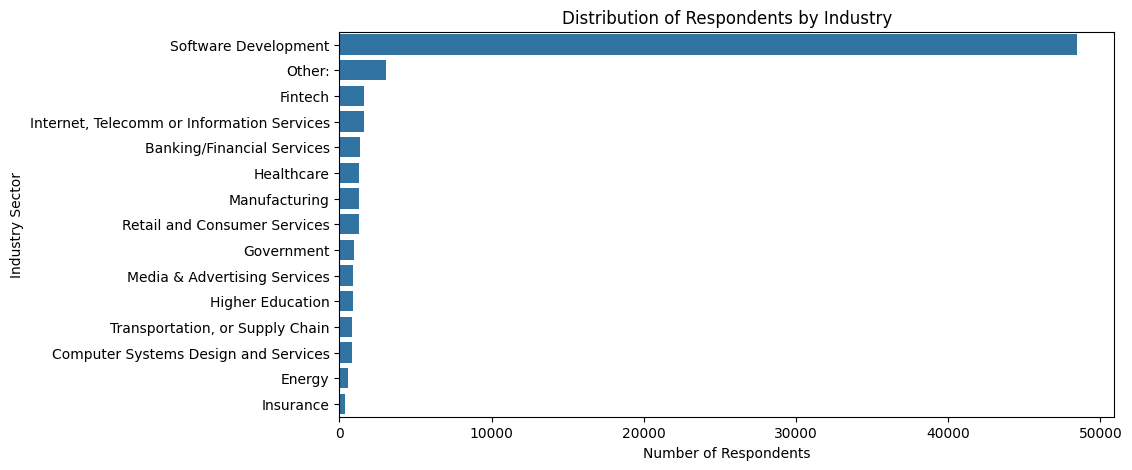

In [56]:
plt.figure(figsize=(10, 5))
sns.countplot(y='Industry', data=df, order=df['Industry'].value_counts().index)
plt.title('Distribution of Respondents by Industry')
plt.xlabel('Number of Respondents')
plt.ylabel('Industry Sector')
plt.show()

Highlight: There is the highest number of respondents in Software Development.

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [57]:
df['ConvertedCompYearly'].describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [59]:
mean_val = df['ConvertedCompYearly'].mean()
std_val = df['ConvertedCompYearly'].std()

# Define threshold
threshold = mean_val + (3 * std_val)

# Identify outliers
outliers = df[df['ConvertedCompYearly'] > threshold]

#print(f"Mean: {mean_val:,.2f}")
#print(f"Standard Deviation: {std_val:,.2f}")
#print(f"Outlier Threshold: {threshold:,.2f}")
print(f"Total Outliers Found: {len(outliers)},\n {outliers[['ResponseId','ConvertedCompYearly']]}")

Total Outliers Found: 89,
        ResponseId  ConvertedCompYearly
529           530             650000.0
828           829            1000000.0
1932         1933             945000.0
2171         2172             750000.0
2187         2188            2000000.0
...           ...                  ...
38219       38220            1000000.0
39643       39644            1300000.0
40066       40067             800000.0
40952       40953             750000.0
41027       41028             700000.0

[89 rows x 2 columns]


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [60]:
##Write your code here
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
# 2. Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

In [62]:
# 3. Define the outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# 4. Identify outliers
outliers = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)]
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Number of Outliers: {len(outliers)}")

Lower Bound: -80177.25
Upper Bound: 220860.75
Number of Outliers: 978


Text(0, 0.5, 'Compensation (Log Scaled)')

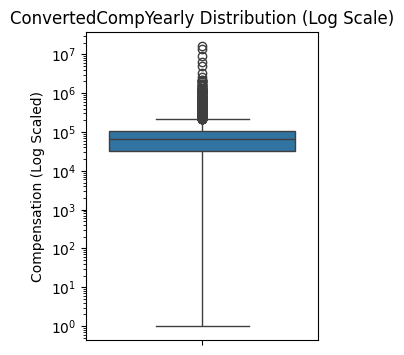

In [69]:
plt.figure(figsize=(3, 4))
sns.boxplot(y='ConvertedCompYearly', data=df)
# Apply a logarithmic scale to the Y-axis
plt.yscale('log')
plt.title('ConvertedCompYearly Distribution (Log Scale)')
plt.ylabel('Compensation (Log Scaled)')

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [70]:
##Write your code here

# 3. Create a new DataFrame excluding outliers
# This filters for values strictly within the bounds
df_cleaned = df[(df['ConvertedCompYearly'] >= lower_bound) & 
                (df['ConvertedCompYearly'] <= upper_bound)]

In [71]:
df_cleaned.shape

(22457, 114)

In [72]:
# Verification: Compare sizes
print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(df_cleaned)}")
print(f"Outliers removed: {len(df) - len(df_cleaned)}")

Original rows: 65437
Cleaned rows: 22457
Outliers removed: 42980


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [73]:
##Write your code here
df['Age'].value_counts()

Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64

In [74]:
# Define the order manually
age_mapping = {
    'Under 18 years old': 1,
    '18-24 years old': 2,
    '25-34 years old': 3,
    '35-44 years old': 4,
    '45-54 years old': 5,
    '55-64 years old': 6,
    '65 years or older': 7
}

# Apply mapping to the DataFrame
df['Age_Numeric'] = df['Age'].map(age_mapping)

In [75]:
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df['CompTotal'] = pd.to_numeric(df['CompTotal'], errors='coerce')

In [76]:
# Compute correlation
correlation_Age_CompTotal = df['Age_Numeric'].corr(df['CompTotal'])
correlation_Age_YearsCodePro = df['Age_Numeric'].corr(df['YearsCodePro'])

In [77]:
print(correlation_Age_CompTotal)
print(correlation_Age_YearsCodePro)

-0.0025553354306506264
0.8226491641854375


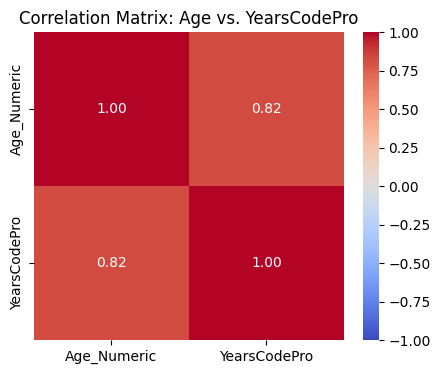

In [80]:
# 1. Select the relevant columns
# Use numeric_only=True to avoid errors with non-numeric data
corr_matrix = df[['Age_Numeric', 'YearsCodePro']].corr()

# 2. Plot the Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, 
            annot=True,      # Show the numeric correlation value in each cell
            cmap='coolwarm', # Blue for negative, Red for positive correlation
            fmt=".2f",       # Format values to 2 decimal places
            vmin=-1, vmax=1, # Fix scale from -1 to 1 for standard correlation
            center=0)

plt.title('Correlation Matrix: Age vs. YearsCodePro')
plt.show()


<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
